# Computer Vision - Kelompok 7

### Library
---

In [30]:
import cv2
import os, zipfile
import numpy as np
import random
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import shutil
import torch
from ultralytics import YOLO
from glob import glob

### Load Data
---

In [36]:
pothole_dir = "pothole_dataset_new"

train_imgs = glob(os.path.join(pothole_dir, 'train', 'images', '*.jpg'))
val_imgs   = glob(os.path.join(pothole_dir, 'valid', 'images', '*.jpg'))
test_imgs  = glob(os.path.join(pothole_dir, 'test',  'images', '*.jpg'))

print(f"Train : {len(train_imgs)} Images")
print(f"Val   : {len(val_imgs)} Images")
print(f"Test  : {len(test_imgs)} Images")
print(f"Total : {len(train_imgs) + len(val_imgs) + len(test_imgs)} Images")

Train : 3076 Images
Val   : 491 Images
Test  : 246 Images
Total : 3813 Images


### Data Preprocessing
---

Set Training, Validation, Parameter

In [37]:
param = {
    'sat_min': -30, 
    'sat_max': 30,
    'val_min': -40,
    'val_max': 40,
    'mean': 0,
    'std_dev': 15,
}

print("Paramenter Augmentation Ready.")

Paramenter Augmentation Ready.


Making Pothole Folder and Data Augmentation

In [39]:
def augmentating(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hue, sat, val = cv2.split(hsv)

    sat_change = random.randint(param['sat_min'], param['sat_max'])
    val_change = random.randint(param['val_min'], param['val_max'])
    sat_aug = cv2.add(sat, sat_change)
    val_aug = cv2.add(val, val_change)

    final_hsv = cv2.merge((hue, sat_aug, val_aug))
    img_aug = cv2.cvtColor(final_hsv, cv2.COLOR_HSV2BGR)
    return img_aug

print("Augmentation Function Ready.")

Augmentation Function Ready.


Preprocessing Function

In [40]:
def preprocessing_new(img_path, output_img_dir, output_lbl_dir):
    """Preprocessing untuk dataset Roboflow yang sudah pre-split."""
    file = os.path.basename(img_path)
    # Label ada di folder labels/ sejajar dengan images/
    label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')

    img = cv2.imread(img_path)
    if img is None:
        return

    # Baca label apa adanya (semua sudah pothole class 0)
    if not os.path.exists(label_path):
        return

    with open(label_path, 'r') as f:
        label_lines = f.readlines()

    if not label_lines:
        return

    # Augmentasi warna HSV
    img_aug = augmentating(img)

    # Resize ke 640x640
    img_resized = cv2.resize(img_aug, (640, 640))

    # Simpan
    cv2.imwrite(os.path.join(output_img_dir, file), img_resized)
    with open(os.path.join(output_lbl_dir, file.replace('.jpg', '.txt')), 'w') as f:
        f.writelines(label_lines)

print("Preprocessing Function Ready.")

Preprocessing Function Ready.


Dataset Training, Testing, Validation

In [ ]:
print("3. Preprocessing in Split")

for split in ['train', 'valid', 'test']:
    img_dir_split = os.path.join(pothole_dir, split, 'images')
    lbl_dir_split = os.path.join(pothole_dir, split, 'labels')

    all_imgs = glob(os.path.join(img_dir_split, '*.jpg'))
    print(f"   Preprocessing {split}: {len(all_imgs)} images...")

    for img_path in all_imgs:
        preprocessing_new(img_path, img_dir_split, lbl_dir_split)

print("\nPreprocessing Complete!")
print(f"Train : {len(glob(os.path.join(pothole_dir, 'train', 'images', '*.jpg')))} images")
print(f"Val   : {len(glob(os.path.join(pothole_dir, 'valid', 'images', '*.jpg')))} images")
print(f"Test  : {len(glob(os.path.join(pothole_dir, 'test',  'images', '*.jpg')))} images")

3. Preprocessing in Split
   Preprocessing train: 3076 images...


### Modelling - YOLOv8
---

Making File Configuration (data.yaml)

In [73]:
yaml_path = os.path.join(pothole_dir, 'data.yaml')

data_config = {
    'train': os.path.abspath(os.path.join(pothole_dir, 'train', 'images')),
    'val':   os.path.abspath(os.path.join(pothole_dir, 'valid', 'images')),
    'test':  os.path.abspath(os.path.join(pothole_dir, 'test',  'images')),
    'nc': 1,
    'names': ['pothole']
}

with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("data.yaml updated :")
with open(yaml_path, 'r') as f:
    print(f.read())

data.yaml updated :
names:
- pothole
nc: 1
test: d:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\pothole_dataset_new\test\images
train: d:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\pothole_dataset_new\train\images
val: d:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\pothole_dataset_new\valid\images



Load YOLOv8 and Training Model

In [ ]:
if os.path.exists('runs'):
    shutil.rmtree('runs')   # Delete Old Training Data

torch.cuda.empty_cache()

model = YOLO('yolov8m.pt')

results = model.train(
    data=os.path.abspath(os.path.join(pothole_dir, 'data.yaml')),
    epochs=25,
    patience=30,    
    imgsz=640,
    batch=16,        
    device=0,

    # Optimizer
    lr0=0.01,           
    lrf=0.01,
    cos_lr=True,
    warmup_epochs=3,
    
    # Augmentasi spatial
    mosaic=1.0,
    mixup=0.15,         
    copy_paste=0.1,    
    degrees=15.0,       
    scale=0.6,
    fliplr=0.5,
    flipud=0.3,
    translate=0.1,
    hsv_s=0.7,
    hsv_v=0.4,
    
    close_mosaic=15,
    
    name='yolov8_pothole_kel7'
)


Ultralytics 8.4.53  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=d:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\pothole_dataset_new\data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yo

### Evaluation Metric and Exporting Model
---

Total Loss and Accuracy Plotting

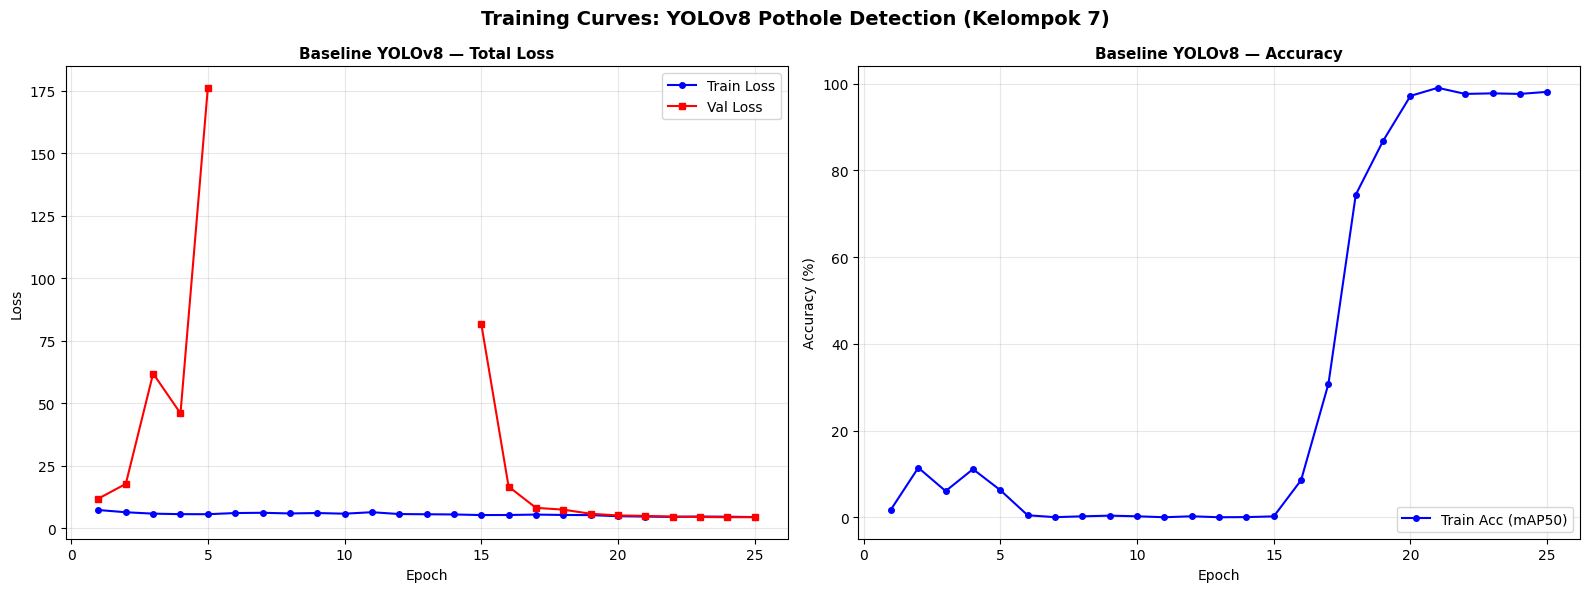

In [45]:
# Force Graph
%matplotlib inline

# Search Training Result Folder
folders = glob('runs/detect/yolov8_pothole_kel7*')

if folders:
    latest_folder = max(folders, key=os.path.getmtime)
    csv_path = os.path.join(latest_folder, 'results.csv')
    
    if os.path.exists(csv_path) and os.path.getsize(csv_path) > 0:
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip() # Clear Whitespace
        
        epochs = df['epoch']
        
        # Total Loss Calculation YOLOv8 (box_loss + cls_loss + dfl_loss)
        train_total_loss = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
        val_total_loss = df['val/box_loss'] + df['val/cls_loss'] + df['val/dfl_loss']
        
        # mAP50 Metric (%)
        accuracy_map50 = df['metrics/mAP50(B)'] * 100
        
        # 2 Graph Plotting
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('Training Curves: YOLOv8 Pothole Detection (Kelompok 7)', fontweight='bold', fontsize=14)
        
        # --- Graph 1 : Total Loss Curve (Left) ---
        axes[0].plot(epochs, train_total_loss, 'b-o', markersize=4, label='Train Loss')
        axes[0].plot(epochs, val_total_loss, 'r-s', markersize=4, label='Val Loss')
        axes[0].set_title('Baseline YOLOv8 — Total Loss', fontweight='bold', fontsize=11)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # --- Graph 2: Accuracy / mAP50 Curve (Right) ---
        axes[1].plot(epochs, accuracy_map50, 'b-o', markersize=4, label='Train Acc (mAP50)')
        axes[1].set_title('Baseline YOLOv8 — Accuracy', fontweight='bold', fontsize=11)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy (%)')
        axes[1].legend(loc='lower right')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print("result.csv doesn't have any value.")
else:
    print("No Training Folder was Found")

Confusion Matrix

Load Confusion Matrix : runs/detect\yolov8_pothole_kel7


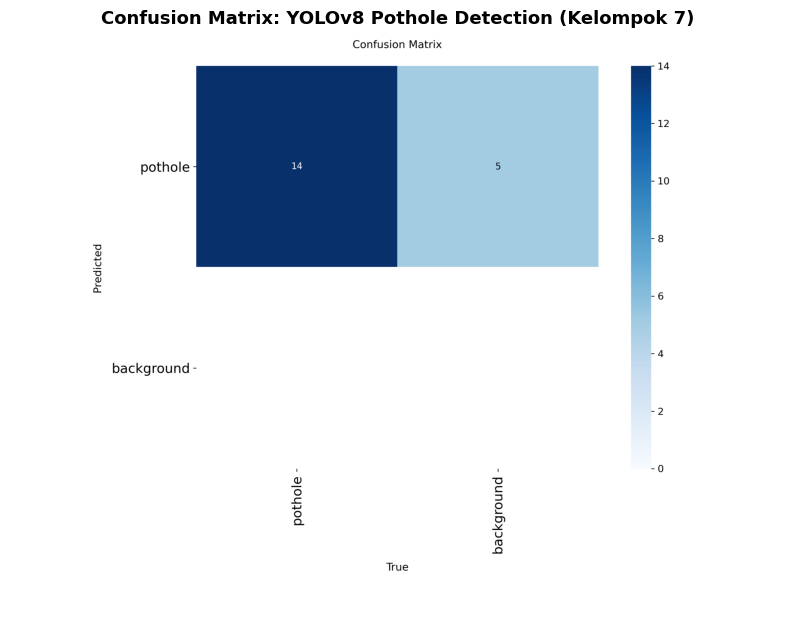

In [77]:
olders = glob('runs/detect/yolov8_pothole_kel7*')

if folders:
    latest_folder = max(folders, key=os.path.getmtime)
    cm_path = os.path.join(latest_folder, 'confusion_matrix.png')
    
    if os.path.exists(cm_path):
        print(f"Load Confusion Matrix : {latest_folder}")
        
        img_bgr = cv2.imread(cm_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(10, 10))
        plt.imshow(img_rgb)
        plt.title("Confusion Matrix: YOLOv8 Pothole Detection (Kelompok 7)", fontweight='bold', fontsize=13)
        plt.axis('off')
        plt.show()
    else:
        print("Confusion Matrix not Found")
        print("Please do the Training First")
else:
    print("Folder training 'runs/detect/yolov8_pothole_kel7' not Found.")

Accuracy, Precision, Recall, and F1-Score

In [ ]:
folders = glob('runs/detect/yolov8_pothole_kel7*')

if folders:
    latest_folder = max(folders, key=os.path.getmtime)
    best_weight = os.path.join(latest_folder, 'weights', 'best.pt')
    
    if os.path.exists(best_weight):
        # Load Saved Model
        saved_model = YOLO(best_weight)
        
        print("--- Evaluation Metric Model ---")
        metrics = saved_model.val(data=os.path.abspath(yaml_path), split='test', conf=0.25, iou=0.5, verbose=False)
        
        # Extract Metric from YOLOv8
        precision = metrics.results_dict['metrics/precision(B)'] * 100
        recall = metrics.results_dict['metrics/recall(B)'] * 100
        map50 = metrics.results_dict['metrics/mAP50(B)'] * 100
        map95 = metrics.results_dict['metrics/mAP50-95(B)'] * 100
        
        # Calculating F1 Score
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        # Set map50 as Accuracy
        accuracy = map50 
        
        # Show Result : Accuracy, Precision, Recall, F1-Score
        print(f"\n Evaluation Result")
        print(f"1. Accuracy (mAP50)     : {accuracy:.2f}%")
        print(f"2. Precision            : {precision:.2f}%")
        print(f"3. Recall               : {recall:.2f}%")
        print(f"4. F1-Score             : {f1_score:.2f}%")
        print(f"5. mAP50-95              : {map95:.2f}%")
        
    else:
        print("File weights 'best.pt' belum terbentuk.")
else:
    print("No Folder Training was Found.")

--- Evaluation Metric Model ---
Ultralytics 8.4.53  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 607.6521.8 MB/s, size: 129.2 KB)
val: Scanning D:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\pothole_dataset_new\test\labels.cache... 246 images, 1 backgrounds, 237 corrupt: 100% ━━━━━━━━━━━━ 246/246  0.0s
val: D:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\pothole_dataset_new\test\images\0000060_jpg.rf.a3f7ae7d19af60c0ad8bd91f688d41f5.jpg: ignoring corrupt image/label: Label class 1 exceeds dataset class count 1. Possible class labels are 0-0
val: D:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\pothole_dataset_new\test\images\000042_r_jpg.rf.cda4916f0fd4d5ae27efcb51da655a5c.jpg: ignoring corrupt image/label: Label class 1 exc

Prediction Potholes and Calculate Road Health Index (RHI)


image 1/1 d:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\pothole_dataset_new\test\images\img-538_jpg.rf.8a7e51519a4cfd817be3c71693117ebd.jpg: 640x640 (no detections), 127.0ms
Speed: 4.1ms preprocess, 127.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


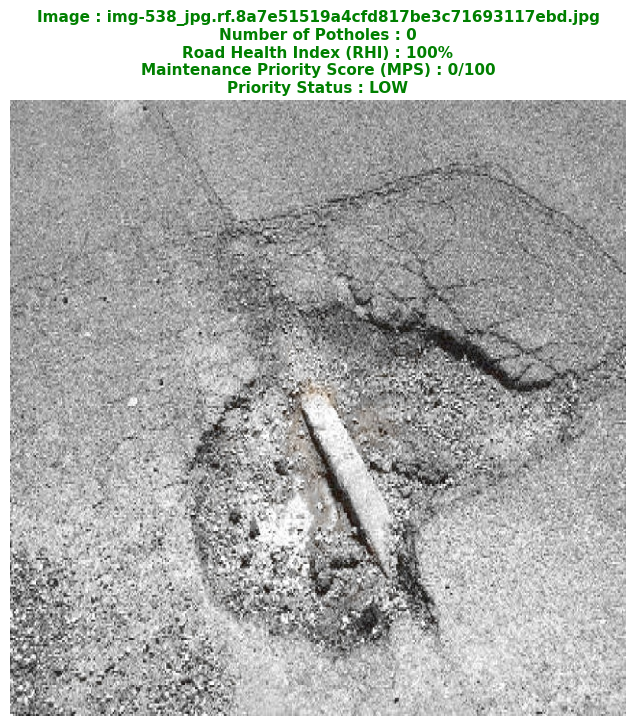

In [80]:
folders = glob('runs/detect/yolov8_pothole_kel7*')

if folders:
    latest_folder = max(folders, key=os.path.getmtime)
    best_weight = os.path.join(latest_folder, 'weights', 'best.pt')
    
    if os.path.exists(best_weight):
        final_model = YOLO(best_weight)
        
        test_images_dir = os.path.join(pothole_dir, 'test', 'images')
        all_test_images = os.listdir(test_images_dir)
        random_image = random.choice(all_test_images)
        sample_path = os.path.join(test_images_dir, random_image)
        
        # Predict Detection
        predictions = final_model(sample_path, conf=0.45)
        
        for result in predictions:
            img_bgr = result.plot()
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            
            num_potholes = len(result.boxes)
            
            # --- ROAD HEALTH INDEX (RHI) ---
            base_health = 100
            deduction_per_pothole = 20 
            rhi_score = max(0, base_health - (num_potholes * deduction_per_pothole))
            
            # --- MAINTENANCE PRIORITY SCORE (MPS) ---
            # Severity of the Potholes based on the size of Bounding Box
            total_severity_score = 0
            
            if num_potholes > 0:
                for box in result.boxes:
                    # Width and Height of Bounding Box
                    w_box = box.xywh[0][2].item()
                    h_box = box.xywh[0][3].item()
                    
                    # Calculating Box Area Percentage
                    box_area_percentage = (w_box * h_box) * 100
                    
                    if box_area_percentage > 5.0:
                        severity_weight = 3.0  # Kategori lubang besar/dalam
                    else:
                        severity_weight = 1.0  # Kategori lubang kecil
                        
                    total_severity_score += (box_area_percentage * severity_weight)
            
            # Normalize MPS Score
            mps_score = min(100, int(total_severity_score * 5))
            
            # Labeling
            if mps_score >= 70 or rhi_score <= 40:
                priority_status = "CRITICAL"
                color_text = 'red'
            elif mps_score >= 40 or rhi_score <= 70:
                priority_status = "MEDIUM"
                color_text = 'yellow'
            else:
                priority_status = "LOW"
                color_text = 'green'
                
            # Menampilkan hasil visualisasi analisis sistem terpadu
            plt.figure(figsize=(11, 8))
            plt.imshow(img_rgb)
            
            title_info = (
                f"Image : {random_image}\n"
                f"Number of Potholes : {num_potholes}\n"
                f"Road Health Index (RHI) : {rhi_score}%\n"
                f"Maintenance Priority Score (MPS) : {mps_score}/100\n"
                f"Priority Status : {priority_status}"
            )
            plt.title(title_info, fontweight='bold', fontsize=11, color=color_text if color_text != 'darkorange' else 'orange')
            plt.axis('off')
            plt.show()
    else:
        print("File weights 'best.pt' not Found.")

In [81]:
print("=== Export Model ke ONNX untuk Node.js ===")

folders = glob('runs/detect/yolov8_pothole_kel7*')
latest_folder = max(folders, key=os.path.getmtime)
best_weight = os.path.join(latest_folder, 'weights', 'best.pt')

final_model = YOLO(best_weight)

# Export ke ONNX
final_model.export(
    format='onnx',
    imgsz=640,
    simplify=True,
    opset=12,
    dynamic=False
)

onnx_path = best_weight.replace('best.pt', 'best.onnx')
print(f"\nFile siap dikirim ke teman: {onnx_path}")
print(f"Ukuran file: {os.path.getsize(onnx_path) / 1024 / 1024:.1f} MB")

=== Export Model ke ONNX untuk Node.js ===
Ultralytics 8.4.53  Python-3.11.9 torch-2.5.1+cu121 CPU (13th Gen Intel Core i7-13620H)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs

PyTorch: starting from 'runs\detect\yolov8_pothole_kel7\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (49.6 MB)

ONNX: starting export with onnx 1.21.0 opset 12...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success  1.7s, saved as 'runs\detect\yolov8_pothole_kel7\weights\best.onnx' (98.8 MB)

Export complete (2.3s)
Results saved to D:\Albert\Binus\Kuliah Semester 4\Computer Vision\Computer-Vision-Project-Binus\runs\detect\yolov8_pothole_kel7\weights\best.onnx
Predict:         yolo predict task=detect model=runs\detect\yolov8_pothole_kel7\weights\best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs\detect\yolov8_pothole_kel7\weights\best.onnx imgsz=640 data=d:\Albert\Binus\Kuliah Semester 4\Computer Vision\Co